## 1. Preprocessing
### 1.1 Load library

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

array = np.ndarray

from itertools import product
import pandas as pd

### 1.2 Load ORL Dataset and Extended YaleB Dataset.
+ ORL dataset contains ten different images of each of 40 distinct subjects. For some subjects, the images were taken at different times, varying the lighting, facial expressions (open / closed eyes, smiling / not smiling) and facial details (glasses / no glasses). All the images were taken against a dark homogeneous background with the subjects in an upright, frontal position (with tolerance for some side movement). The size of each image is 92x112 pixels, with 256 grey levels per pixel. To further reduce the computation complexity, you can resize all images to 30x37 pixels.

+ Extended YaleB dataset contains 2414 images of 38 human subjects under 9 poses and 64 illumination conditions. All images are manually aligned, cropped, and then resized to 168x192 pixels. To further reduce the computation complexity, you can resize all images to 42x48 pixels.

In [2]:
root_ORL = 'data/ORL'
img_resize_ORL = (37,30)
root_YaleB = 'data/CroppedYaleB'
img_resize_YaleB = (48,42)
max_iter_nmf = 5000
max_iter_L21_nmf = 5000

In [3]:
import logging

# Create logger
logger = logging.getLogger("logger")
logger.setLevel(logging.DEBUG)

train_handler = logging.FileHandler("train.log", mode="w", encoding="utf-8")
train_handler.setLevel(logging.INFO)
train_formatter = logging.Formatter("%(asctime)s - %(levelname)s - %(message)s")
train_handler.setFormatter(train_formatter)

debug_handler = logging.FileHandler("debug.log", mode="w", encoding="utf-8")
debug_handler.setLevel(logging.DEBUG)
debug_formatter = logging.Formatter(
    "%(asctime)s - [%(levelname)s] - %(filename)s:%(lineno)d - %(message)s"
)
debug_handler.setFormatter(debug_formatter)

logger.addHandler(train_handler)
logger.addHandler(debug_handler)

result_logger = logging.getLogger("result_logger")
result_logger.setLevel(logging.INFO)

result_handler = logging.FileHandler("result.log", mode="w", encoding="utf-8")
result_formatter = logging.Formatter("%(asctime)s - [RESULT] - %(message)s")
result_handler.setFormatter(result_formatter)

result_logger.addHandler(result_handler)
result_logger.propagate = False

In [4]:
def load_data(root='data/CroppedYaleB', img_resize = (1,1)):
    """ 
    Load ORL (or Extended YaleB) dataset to numpy array.
    
    Args:
        root: path to dataset.
        reduce: scale factor for zooming out images.
        
    """ 
    images, labels = [], []

    for i, person in enumerate(sorted(os.listdir(root))):
        
        if not os.path.isdir(os.path.join(root, person)):
            continue
        
        for fname in os.listdir(os.path.join(root, person)):    
            
            # Remove background images in Extended YaleB dataset.
            if fname.endswith('Ambient.pgm'):
                continue
            
            if not fname.endswith('.pgm'):
                continue
                
            # load image.
            img = Image.open(os.path.join(root, person, fname))
            img = img.convert('L') # grey image.

            # reduce computation complexity.
            img = img.resize(img_resize)

            # TODO: preprocessing.

            # convert image to numpy array.
            img = np.asarray(img).reshape((-1,1)).astype(np.float32)
            img = img / 255.0  # normalization to [0,1]

            # collect data and label.
            images.append(img)
            labels.append(i)

    # concate all images and labels.
    images = np.concatenate(images, axis=1)
    labels = np.array(labels)

    return images, labels

In [5]:
# Load ORL dataset.
ORL_X, ORL_Y = load_data(root=root_ORL, img_resize=img_resize_ORL)
print('ORL dataset: X.shape = {}, Y.shape = {}'.format(ORL_X.shape, ORL_Y.shape))

# Load Extended YaleB dataset.
YaleB_X, YaleB_Y = load_data(root=root_YaleB, img_resize = img_resize_YaleB)
print('Extended YalB dataset: X.shape = {}, Y.shape = {}'.format(YaleB_X.shape, YaleB_Y.shape))

ORL dataset: X.shape = (1110, 400), Y.shape = (400,)
Extended YalB dataset: X.shape = (2016, 2414), Y.shape = (2414,)


### 1.2 Dataset pre-show

In [6]:
# A function to show the examples in dataset.

def examples(dataset, n_rows = 5, n_cols = 10, img_resize = (1,1,1)):

    faces = dataset.T.reshape(img_resize)

    plt.figure(figsize=(n_cols, n_rows))
    plt.axis('off')

    for r in range(n_rows):
        for c in range(n_cols):

            index = r * 10 + c

            plt.subplot(n_rows, n_cols, index+1)
            plt.axis('off')
            plt.imshow(faces[index], cmap= "gray" )

        
    plt.show()

Some examples img of ORL dataset


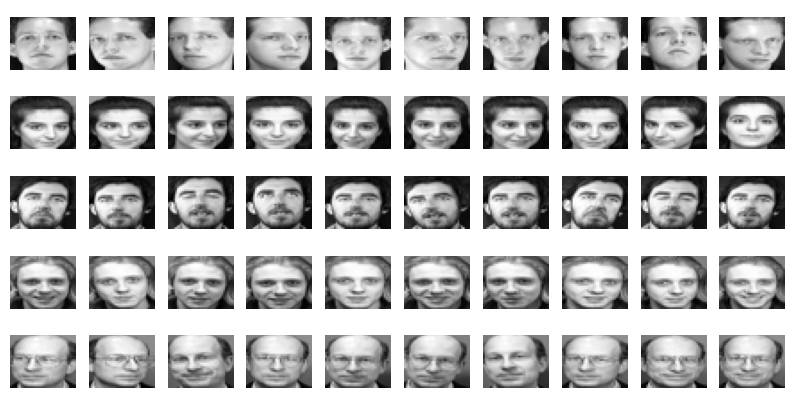

First 10 examples of y_train: [2 2 2 2 2 2 2 2 2 2]


In [7]:
print(f"Some examples img of ORL dataset")
examples(ORL_X, img_resize = (400,30,37))
print(f"First 10 examples of y_train: {ORL_Y[0:10]}")

Some examples img of YaleB dataset


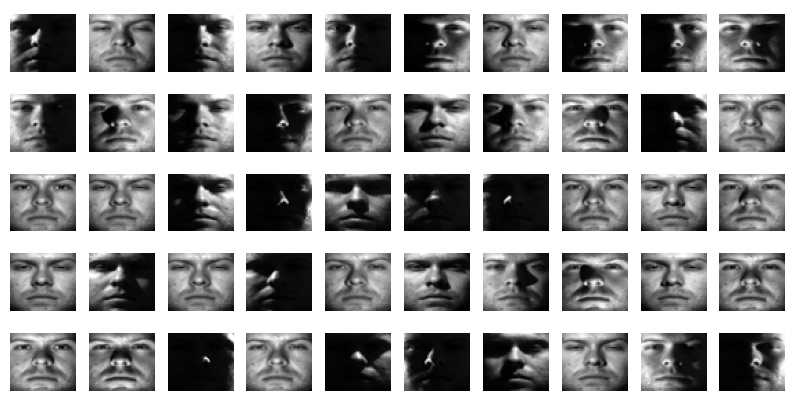

First 10 examples of y_train: [1 1 1 1 1 1 1 1 1 1]


In [8]:
print(f"Some examples img of YaleB dataset")
examples(YaleB_X, img_resize = (2414,42,48))
print(f"First 10 examples of y_train: {YaleB_Y[0:10]}")

## 2. Main NMF Algorithm

### 2.1 Standard NMF (L2 NMF) Algorithm

In [9]:
def nmf_standard(V, y, eps=1e-10, seed=0, maxiter = max_iter_nmf):
    """
    Standard NMF (L2 NMF)
    V: d * n non-negative matrix
    k: rank for factorization
    """
    d, n = V.shape

    # Initial iter matrix
    # Here rank is usually to choose close to the examples of dataset.
    k = len(np.unique(y))

    # init W, H
    np.random.seed(seed)
    W = np.random.random((d, k))
    H = np.random.random((k, n))

    diff = float('Inf')
    iters = 0

    while (iters < maxiter) and (diff > eps):
        # update H
        WH = np.dot(W, H)
        H_new = H * (np.dot(W.T, V)) / (np.dot(W.T, WH) + 1e-12)

        # update W
        WH = np.dot(W, H_new)
        W_new = W * (np.dot(V, H_new.T)) / (np.dot(W, np.dot(H_new, H_new.T)) + 1e-12)

        # non-negativity
        W_new = np.clip(W_new, 0, None)
        H_new = np.clip(H_new, 0, None)

        # check convergence
        diff_W = np.linalg.norm(W_new - W)
        diff_H = np.linalg.norm(H_new - H)
        diff = diff_W + diff_H

        # update W, H
        W, H = W_new, H_new

        iters += 1

    logger.debug(f"Converged after {iters} iterations, diff={diff:.3e}")
    return W, H

### 2.2 L2,1-Norm Based NMF Algorithm

In [10]:
# Function to check if the Matrix is positive or not.

def check_positive(X:array):
    if np.any(X<0):
        raise ValueError(f'The matrix {X} is not a Non-negative Matrix')

In [11]:
# Algorithm

def L21_norm_based_NMF(X:array, y:array, name:str, 
                                random_state:int | None = 42,
                                max_iter = max_iter_L21_nmf,
                                convergence_criterion = 1e-7):
    '''
    
    '''
    check_positive(X)
    m,n = X.shape
    rng = np.random.default_rng(random_state)

    # In case to happen that the Denominator=0
    eps = 1e-12 

    # Record the iteration
    history = []

    # Initial iter matrix
    # Here rank is usually to choose close to the examples of dataset.
    rank = len(np.unique(y))

    F = rng.random((m,rank))+1e-8 
    G = rng.random((rank,n))+1e-8

    X_sq = np.sum(X * X, axis=0)

    
    for i in range(max_iter):

        # Compute D Matrix
        F_G = F @ G
        F_G_sq = np.sum(F_G * F_G, axis=0)
        cross = np.sum(X * F_G, axis=0)
        D_denominator = np.sqrt(np.maximum(X_sq + F_G_sq - 2 * cross,0.0)) + eps
        D = 1.0 / np.maximum(D_denominator,eps)

        # Update F
        X_D = X * D
        G_D = G * D
        F_molecular = X_D @ G.T
        F_denominator = F @ (G_D @ G.T) + eps
        F_denominator = np.maximum(F_denominator,eps)

        np.divide(F_molecular, F_denominator, out=F_molecular)
        F *= F_molecular
        F = np.maximum(F,eps) # Make sure non-negative.

        # Update G
        G_molecular = F.T @ X_D
        G_denominator = F.T @ F @ G * D + eps
        G_denominator = np.maximum(G_denominator,eps)

        np.divide(G_molecular, G_denominator, out=G_molecular)
        G *= G_molecular
        G = np.maximum(G,eps) # Make sure non-negative.

        # Update residual
        residual = D_denominator
        history.append(np.sum(residual))

        if i > 0:
            convergence_new = abs(history[-1] - history[-2]) / (history[-2] + eps)
            if convergence_new < convergence_criterion:
                logger.debug(f'Reached the convergence criterion. Total iterative number: {i+1}.')
                break
        
        if i == max_iter - 1:
            logger.debug(f'Reached the max iteration. Last convergence rate: {convergence_new}.')

    return F, G
    

## 3. Evaluation Metrics




## 3.1 Add salt & pepper noise

Pre-show of noise plot.

In [12]:
# Add salt & pepper noise Algorithm

def add_salt_pepper(X, p, r, seed, vmax=1.0):
    """
    Args:
        X    : numpy array of shape (d, n), values in [0,1].
        p    : fraction of pixels to be corrupted per image.
        r    : fraction of corrupted pixels set to salt (vmax); the rest are pepper (0).
        seed : random seed (to be reproducible).
        vmax : maximum pixel value (default 1.0 after normalization).
    """
    d, n = X.shape
    np.random.seed(seed)
    Xn = X.copy()

    m = int(round(p * d))     # number of pixels to corrupt per column
    if m <= 0:
        return Xn
    k = int(round(r * m))     # number of salt pixels (set to vmax)

    for j in range(n):
        idx = np.random.choice(d, size=m, replace=False)
        # salt: set selected pixels to vmax
        Xn[idx[:k], j] = vmax
        # pepper: set the remaining to 0
        Xn[idx[k:], j] = 0.0
    return Xn

In [13]:
# Plot pre-show

def Noise_pre_show(root, img_resize, name:str):

    # Load dataset.
    print(f'==> Load {name} dataset ...')
    V_hat, Y_hat = load_data(root=root, img_resize = img_resize)
    print('V_hat.shape={}, Y_hat.shape={}'.format(V_hat.shape, Y_hat.shape))

    # Add salt & pepper noise.
    p, r = 0.2, 0.7 
    V = add_salt_pepper(V_hat, p=p, r=r, seed=0, vmax=1.0)

    # Derive a pure noise image (for visualization).
    V_noise = V - V_hat

    # Plot result.
    img_size = img_resize
    ind = 2  # index of demo image.

    plt.figure(figsize=(10,3))

    # Original
    plt.subplot(131)
    plt.imshow(V_hat[:,ind].reshape(img_size[1], img_size[0]), cmap=plt.cm.gray)
    plt.title('Image (Original)')

    # Noise only
    plt.subplot(132)
    plt.imshow(V_noise[:,ind].reshape(img_size[1], img_size[0]), cmap=plt.cm.gray)
    plt.title('Noise')

    # Noisy image
    plt.subplot(133)
    plt.imshow(V[:,ind].reshape(img_size[1], img_size[0]), cmap=plt.cm.gray)
    plt.title('Image (Noisy)')
    plt.show()

==> Load ORL dataset ...
V_hat.shape=(1110, 400), Y_hat.shape=(400,)


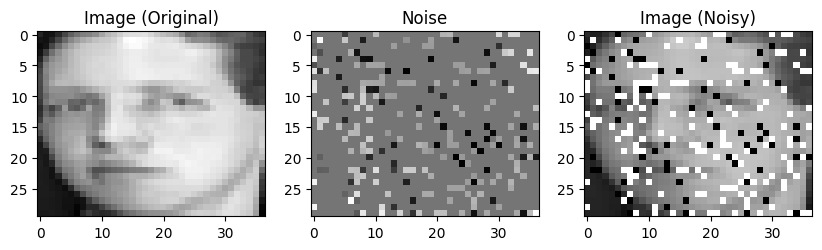

In [14]:
Noise_pre_show(root = root_ORL, img_resize=img_resize_ORL, name = "ORL")

==> Load YaleB dataset ...
V_hat.shape=(2016, 2414), Y_hat.shape=(2414,)


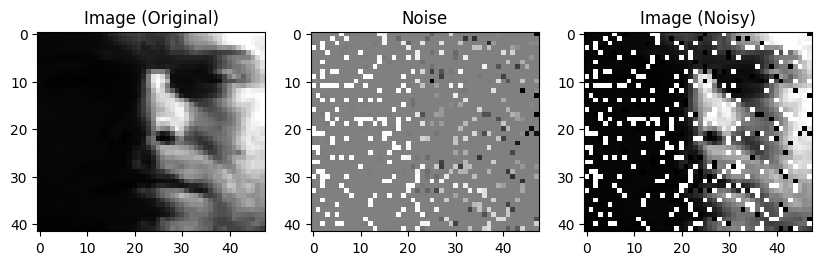

In [15]:
Noise_pre_show(root = root_YaleB, img_resize=img_resize_YaleB, name = "YaleB")

In [16]:
# Plot pre-show below different p and r.

def Noise_pre_show_pr(root, img_resize, name:str):
    
    print(f'==> Load {name} dataset ...')
    V_hat, Y_hat = load_data(root=root, img_resize = img_resize)
    print('V_hat.shape={}, Y_hat.shape={}'.format(V_hat.shape, Y_hat.shape))

    # Example index
    ind = 7
    img_size = img_resize

    # Original
    img_a = V_hat[:, ind].reshape(img_size[1], img_size[0])
    # p=0.2, r=0.1
    img_b = add_salt_pepper(V_hat, p=0.2, r=0.1, seed=0, vmax=1.0)[:, ind].reshape(img_size[1], img_size[0])
    # p=0.2, r=0.7
    img_c = add_salt_pepper(V_hat, p=0.2, r=0.7, seed=0, vmax=1.0)[:, ind].reshape(img_size[1], img_size[0])
    # p=0.4, r=0.1
    img_d = add_salt_pepper(V_hat, p=0.4, r=0.1, seed=0, vmax=1.0)[:, ind].reshape(img_size[1], img_size[0])
    # p=0.4, r=0.7
    img_e = add_salt_pepper(V_hat, p=0.4, r=0.7, seed=0, vmax=1.0)[:, ind].reshape(img_size[1], img_size[0])
    # p=0.6, r=0.1
    img_f = add_salt_pepper(V_hat, p=0.6, r=0.1, seed=0, vmax=1.0)[:, ind].reshape(img_size[1], img_size[0])

    plt.figure(figsize=(9, 6))
    plt.subplot(2,3,1); plt.imshow(img_a, cmap='gray'); plt.title("(a) p=0(Original)")
    plt.subplot(2,3,2); plt.imshow(img_b, cmap='gray'); plt.title("(b) p=0.2,r=0.1")
    plt.subplot(2,3,3); plt.imshow(img_c, cmap='gray'); plt.title("(c) p=0.2,r=0.7")
    plt.subplot(2,3,4); plt.imshow(img_d, cmap='gray'); plt.title("(d) p=0.4,r=0.1")
    plt.subplot(2,3,5); plt.imshow(img_e, cmap='gray'); plt.title("(e) p=0.4,r=0.7")
    plt.subplot(2,3,6); plt.imshow(img_f, cmap='gray'); plt.title("(f) p=0.6,r=0.1")
    plt.tight_layout()
    plt.show()

==> Load ORL dataset ...
V_hat.shape=(1110, 400), Y_hat.shape=(400,)


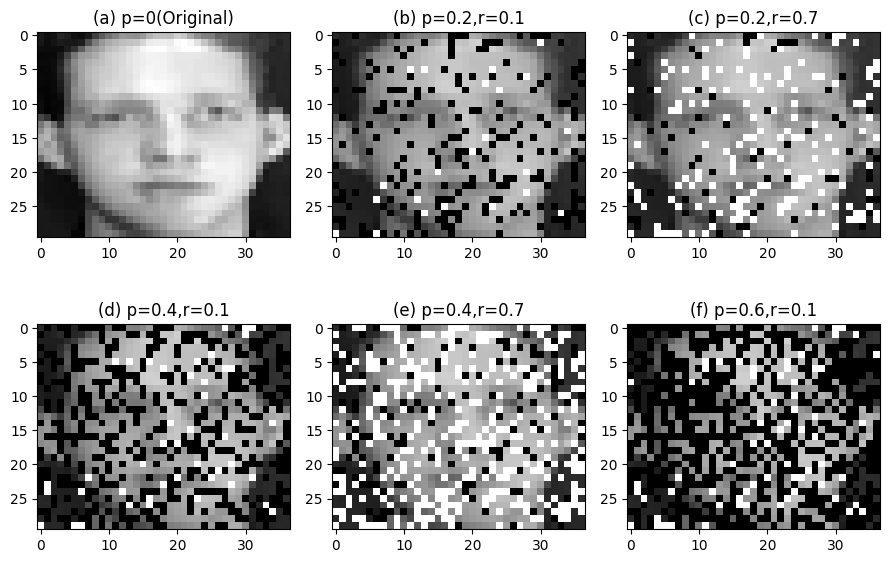

In [17]:
Noise_pre_show_pr(root = root_ORL, img_resize=img_resize_ORL, name = "ORL")

==> Load YaleB dataset ...
V_hat.shape=(2016, 2414), Y_hat.shape=(2414,)


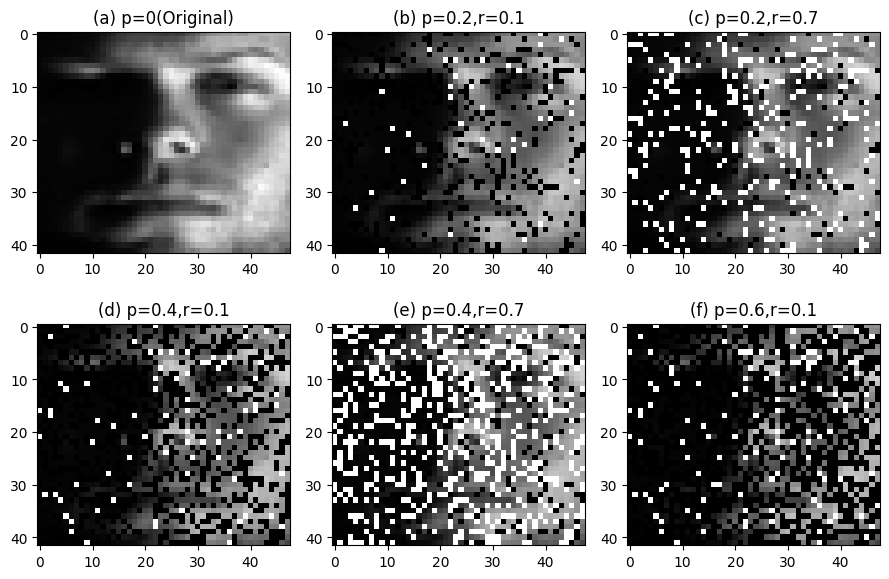

In [18]:
Noise_pre_show_pr(root = root_YaleB, img_resize=img_resize_YaleB, name = "YaleB")

### 3.2 Calculate W and H for each parameters and iterations

In [19]:
WH_records = {}

# Function to record W & H once

def record_WH(p, r, method:str, name:str, ratio = 0.9, num=5, WH_records = WH_records, seed=0):
    """
    Origin_X : clean data matrix (d * n)
    p, r    : noise parameters
    k       : rank for NMF
    num     : number of repetitions
    seed    : random seed
    add_noise: function to add noise
    nmf_func : NMF function
    L_21_norm_based_NMF : L_21_norm_based_NMF function
    """
    if name == "ORL":
        Origin_X,Origin_y = load_data(root = root_ORL, img_resize = img_resize_ORL)
    if name == "YaleB":
        Origin_X,Origin_y = load_data(root = root_YaleB, img_resize = img_resize_YaleB)

    n_samples = Origin_X.shape[1]
    n_train = int(n_samples * ratio)

    for t in range(num):

        logger.info(f'Start calculate W and H in ({name}) using ({method}) with p = {p}, r={r}, seed = {t}')

        # 90% sample
        rng = np.random.default_rng(seed=t)
        indices = rng.permutation(n_samples)

        # Collect the ratio of data.
        test_idx = indices[:n_train]
        X_test, y_test = Origin_X[:,test_idx], Origin_y[test_idx]
        V_hat, Y_hat = X_test, y_test

        # add salt & pepper noise
        V_noisy = add_salt_pepper(V_hat, p=p, r=r, seed=seed+t, vmax=1.0)

        # factorize noisy data
        if method == "L2_norm_NMF":
            W, H = nmf_standard(V_noisy, Y_hat, eps=1e-7)
        if method == "L21_norm_based_NMF":
            W, H = L21_norm_based_NMF(X = V_noisy, y = Y_hat, name = name)
        
        WH_records[(name, method, p, r, t, "W")] = np.asarray(W)
        WH_records[(name, method, p, r, t, "H")] = np.asarray(H)
        WH_records[(name, method, p, r, t, "V_hat")] = np.asarray(V_hat)
        WH_records[(name, method, p, r, t, "Y_hat")] = np.asarray(Y_hat)

        logger.info(f'W = {W}')
        logger.info(f'H = {H}')
        logger.info(f'--------------------------------------------')
    
    return WH_records

# Function to evaluate all dataset and algorithm

def All_WH():
    datasets = ["ORL", "YaleB"]
    methods = ["L2_norm_NMF","L21_norm_based_NMF"] # 
    ps = [0.2,0.4,0.6]
    rs = [0.1,0.4,0.7]

    for p, r, name, method in product(ps, rs, datasets, methods):
        WH_records = record_WH(p = p, r = r, method = method, name = name)

    return WH_records

In [20]:
WH_records = All_WH()

KeyboardInterrupt: 


### 3.3 Relative Reconstruction Errors (RRE)

To compare the robustness of different NMF algorithms, you can use the ```relative reconstruction errors```. Let $V$ denote the contaminated dataset (by adding noise), and $\hat{V}$
 denote the clean dataset. Let $W$ and $H$ denote the factorization results on $V$, the ``relative reconstruction errors`` then can be defined as follows:
\begin{equation}
    RRE = \frac{ \| \hat{V} - WH \|_F }{ \| \hat{V} \|_F}.
\end{equation}

In [ ]:
# Main function
def rre_score(W,H,V_hat):
    rre = np.linalg.norm(V_hat - W.dot(H),'fro') / np.linalg.norm(V_hat,'fro')
    return rre

def calculate_rre(WH_records):

    datasets = ["ORL", "YaleB"]
    methods = ["L2_norm_NMF","L21_norm_based_NMF"]
    ps = [0.2,0.4,0.6]
    rs = [0.1,0.4,0.7]
    seed = range(5)

    rre_records = {}

    for p, r, name, method in product(ps, rs, datasets, methods):
        rre_list = []
        for t in seed:
            W = WH_records[name, method, p, r, t, "W"]
            H = WH_records[name, method, p, r, t, "H"]
            V_hat = WH_records[name, method, p, r, t, "V_hat"]
            rre_list.append(rre_score(W,H,V_hat))
        
        mean = round(float(np.mean(rre_list)),8)
        std = round(float(np.std(rre_list)),8)

        logger.info(f'RRE score on ({name}) using ({method}) with p = {p}, r = {r}, mean = {mean}, std = {std}')

        rre_records[(name, method, float(p), float(r))] = {
        "rre_mean": mean,
        "rre_std": std,
        }
    
    return rre_records

In [ ]:
rre_records = calculate_rre(WH_records)

In [ ]:
# Summary rre records

rows = [
    {
        "dataset": k[0],
        "nmf_method": k[1],
        "p": k[2],
        "r": k[3],
        "rre_mean": v["rre_mean"],
        "rre_std": v["rre_std"],
    }
    for k, v in rre_records.items()
]

df_rre = pd.DataFrame(rows)
print(df_rre)
result_logger.info(f'RRE Results:')
result_logger.info(f'{df_rre}')

   dataset          nmf_method    p    r  rre_mean   rre_std
0      ORL         L2_norm_NMF  0.2  0.1  0.270295  0.000517
1      ORL  L21_norm_based_NMF  0.2  0.1  0.269087  0.000582
2    YaleB         L2_norm_NMF  0.2  0.1  0.257384  0.000547
3    YaleB  L21_norm_based_NMF  0.2  0.1  0.256235  0.000320
4      ORL         L2_norm_NMF  0.2  0.4  0.248753  0.000753
5      ORL  L21_norm_based_NMF  0.2  0.4  0.248951  0.000938
6    YaleB         L2_norm_NMF  0.2  0.4  0.261665  0.000199
7    YaleB  L21_norm_based_NMF  0.2  0.4  0.261719  0.000645
8      ORL         L2_norm_NMF  0.2  0.7  0.281011  0.000697
9      ORL  L21_norm_based_NMF  0.2  0.7  0.280894  0.000928
10   YaleB         L2_norm_NMF  0.2  0.7  0.355025  0.000568
11   YaleB  L21_norm_based_NMF  0.2  0.7  0.354156  0.000653
12     ORL         L2_norm_NMF  0.4  0.1  0.414936  0.000245
13     ORL  L21_norm_based_NMF  0.4  0.1       NaN       NaN
14   YaleB         L2_norm_NMF  0.4  0.1  0.394043  0.000304
15   YaleB  L21_norm_bas


Dataset ORL RRE Summary
             pr  L2   L2_mean    L2_std  L21  L21_mean   L21_std
0  p=0.2, r=0.1  L2  0.270295  0.000517  L21  0.269087  0.000582
1  p=0.2, r=0.4  L2  0.248753  0.000753  L21  0.248951  0.000938
2  p=0.2, r=0.7  L2  0.281011  0.000697  L21  0.280894  0.000928
3  p=0.4, r=0.1  L2  0.414936  0.000245  L21       NaN       NaN
4  p=0.4, r=0.4  L2  0.347132  0.000819  L21       NaN       NaN
5  p=0.4, r=0.7  L2  0.421824  0.001625  L21       NaN       NaN
6  p=0.6, r=0.1  L2  0.556032  0.000637  L21       NaN       NaN
7  p=0.6, r=0.4  L2  0.427718  0.001062  L21       NaN       NaN
8  p=0.6, r=0.7  L2  0.546856  0.001721  L21       NaN       NaN

Dataset YaleB RRE Summary
             pr  L2   L2_mean    L2_std  L21  L21_mean   L21_std
0  p=0.2, r=0.1  L2  0.257384  0.000547  L21  0.256235  0.000320
1  p=0.2, r=0.4  L2  0.261665  0.000199  L21  0.261719  0.000645
2  p=0.2, r=0.7  L2  0.355025  0.000568  L21  0.354156  0.000653
3  p=0.4, r=0.1  L2  0.394043  0.00030

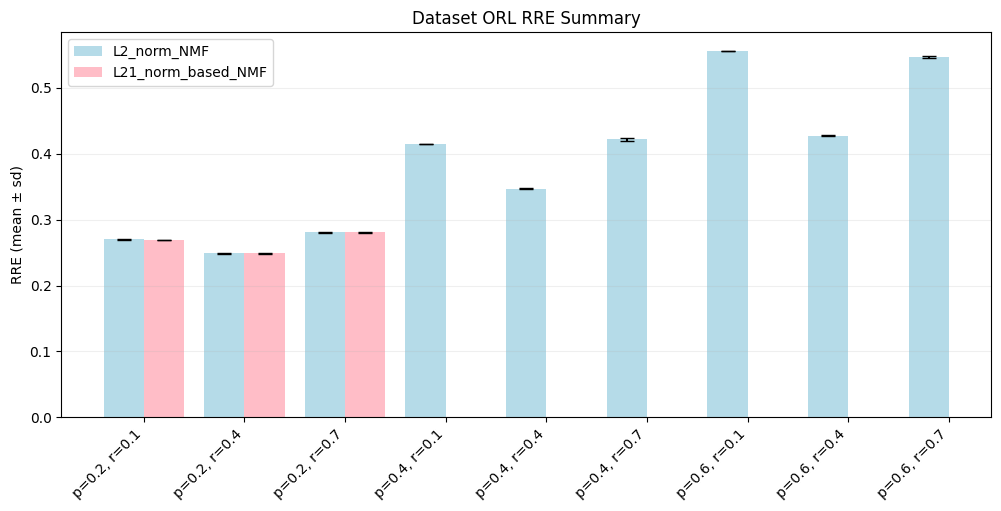

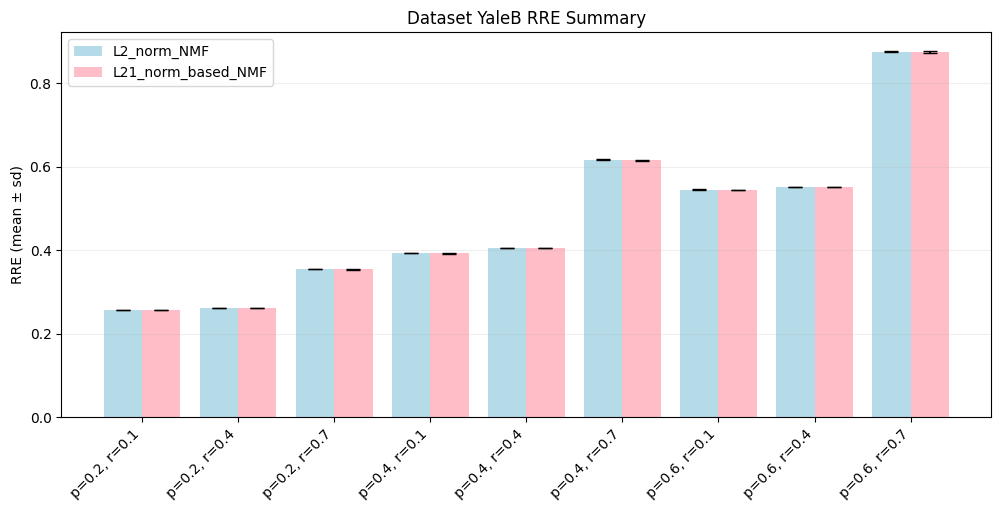

In [ ]:
# Summary for the combination of p and r (RRE)
datasets = df_rre["dataset"].unique()

for ds in datasets:
    df_ds = df_rre[df_rre["dataset"] == ds].copy()
    pr_records = []
    prs = df_ds[["p","r"]].drop_duplicates().sort_values(["p","r"]).values

    for ps, rs in prs:
        sub_l2 = df_ds[(df_ds["nmf_method"]=="L2_norm_NMF") &
                       (df_ds["p"]==ps) & (df_ds["r"]==rs)]

        sub_l21 = df_ds[(df_ds["nmf_method"]=="L21_norm_based_NMF") &
                        (df_ds["p"]==ps) & (df_ds["r"]==rs)]

        pr_records.append([
            f"p={ps}, r={rs}",
            "L2",
            float(sub_l2["rre_mean"].values[0]),
            float(sub_l2["rre_std"].values[0]),
            "L21",
            float(sub_l21["rre_mean"].values[0]),
            float(sub_l21["rre_std"].values[0]),
        ])

    pr_summary = pd.DataFrame(pr_records, columns=[
        "pr", "L2", "L2_mean", "L2_std",
        "L21", "L21_mean", "L21_std"
    ])
    print(f"\nDataset {ds} RRE Summary")
    print(pr_summary)
    result_logger.info(f'Dataset {ds} RRE Summary')
    result_logger.info(f'{pr_summary}')

    #bar plot
    x = np.arange(len(pr_summary))
    w = 0.4

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - w/2, pr_summary["L2_mean"],  yerr=pr_summary["L2_std"],  width=w, capsize=5, label="L2_norm_NMF",color="lightblue",alpha=0.9)
    ax.bar(x + w/2, pr_summary["L21_mean"], yerr=pr_summary["L21_std"], width=w, capsize=5, label="L21_norm_based_NMF",color="lightpink",alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(pr_summary["pr"], rotation=45, ha="right")
    ax.set_ylabel("RRE (mean ± sd)")
    ax.set_title(f"Dataset {ds} RRE Summary")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)

In [ ]:
# Function to create table to visualize the result.
def table_visual(X:list,metric):
    table = X.pivot(index="p", columns="r", values=metric)
    print(table)
    result_logger.info(f'{table}')

# Table Visualization
metrics = ["rre_mean","rre_std"]
methods = ["L2_norm_NMF","L21_norm_based_NMF"]
ps = [0.2,0.4,0.6]
rs = [0.1,0.4,0.7]
print('The value of columns is r while the value of index is p.')

for metric, name, method in product(metrics, datasets, methods):
    print('-')
    print(f'RRE {metric} for dataset "{name}" using algorithm "{method}":')
    result_logger.info(f'RRE {metric} for dataset "{name}" using algorithm "{method}":')
    sub = df_rre[(df_rre["dataset"] == name) & (df_rre["nmf_method"] == method)]
    table_visual(sub, metric)

The value of columns is r while the value of index is p.
-
RRE rre_mean for dataset "ORL" using algorithm "L2_norm_NMF":
r         0.1       0.4       0.7
p                                
0.2  0.270295  0.248753  0.281011
0.4  0.414936  0.347132  0.421824
0.6  0.556032  0.427718  0.546856
-
RRE rre_mean for dataset "ORL" using algorithm "L21_norm_based_NMF":
r         0.1       0.4       0.7
p                                
0.2  0.269087  0.248951  0.280894
0.4       NaN       NaN       NaN
0.6       NaN       NaN       NaN
-
RRE rre_mean for dataset "YaleB" using algorithm "L2_norm_NMF":
r         0.1       0.4       0.7
p                                
0.2  0.257384  0.261665  0.355025
0.4  0.394043  0.405101  0.616710
0.6  0.545169  0.551290  0.875630
-
RRE rre_mean for dataset "YaleB" using algorithm "L21_norm_based_NMF":
r         0.1       0.4       0.7
p                                
0.2  0.256235  0.261719  0.354156
0.4  0.392313  0.404884  0.615204
0.6  0.544285  0.551336

In [ ]:
# Compare algorithm in the same p,r,dataset with mean and std metrics.

def plot_rre():
    # Transfer dict into dataframe
    df = df_rre

    colors = ["#1f77b4", "#ff7f0e"]

    # plot
    for dataset in datasets:
        fig, axes = plt.subplots(
            nrows=1, ncols=len(ps)*len(rs),
            figsize=(3*len(ps)*len(rs), 5), 
            sharey=False
        )

        for k, (p, r) in enumerate(product(ps, rs)):
            ax = axes[k]
            sub = df[(df["dataset"] == dataset) &
                    (df["p"] == p) &
                    (df["r"] == r)]

            x = range(len(methods))
            means = sub.set_index("nmf_method").loc[methods]["rre_mean"]
            stds  = sub.set_index("nmf_method").loc[methods]["rre_std"]

            for xi, (m, mean, std) in enumerate(zip(methods, means, stds)):
                ax.bar(xi, mean, yerr=std, capsize=5, alpha=0.9,
                    color=colors[xi], label=m if k == 0 else "")
            ax.set_xticks(x)
            ax.set_xticklabels(methods, rotation=45)
            ax.set_title(f"p={p}, r={r}", fontsize=10)
            if k == 0:
                ax.set_ylabel("Mean ± Std")

        plt.suptitle(f"Dataset = {dataset}", fontsize=14)
        plt.tight_layout()
        plt.show()

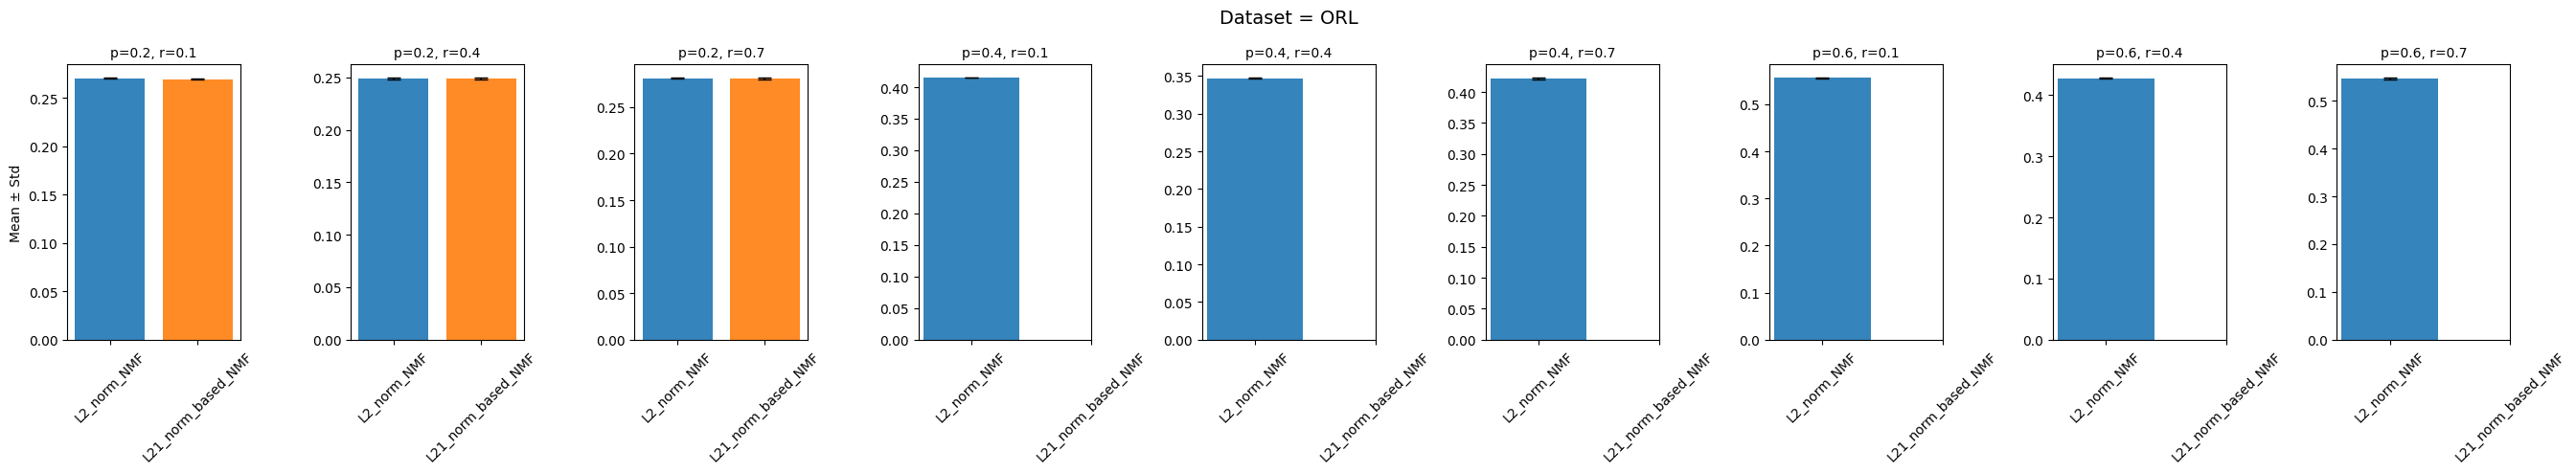

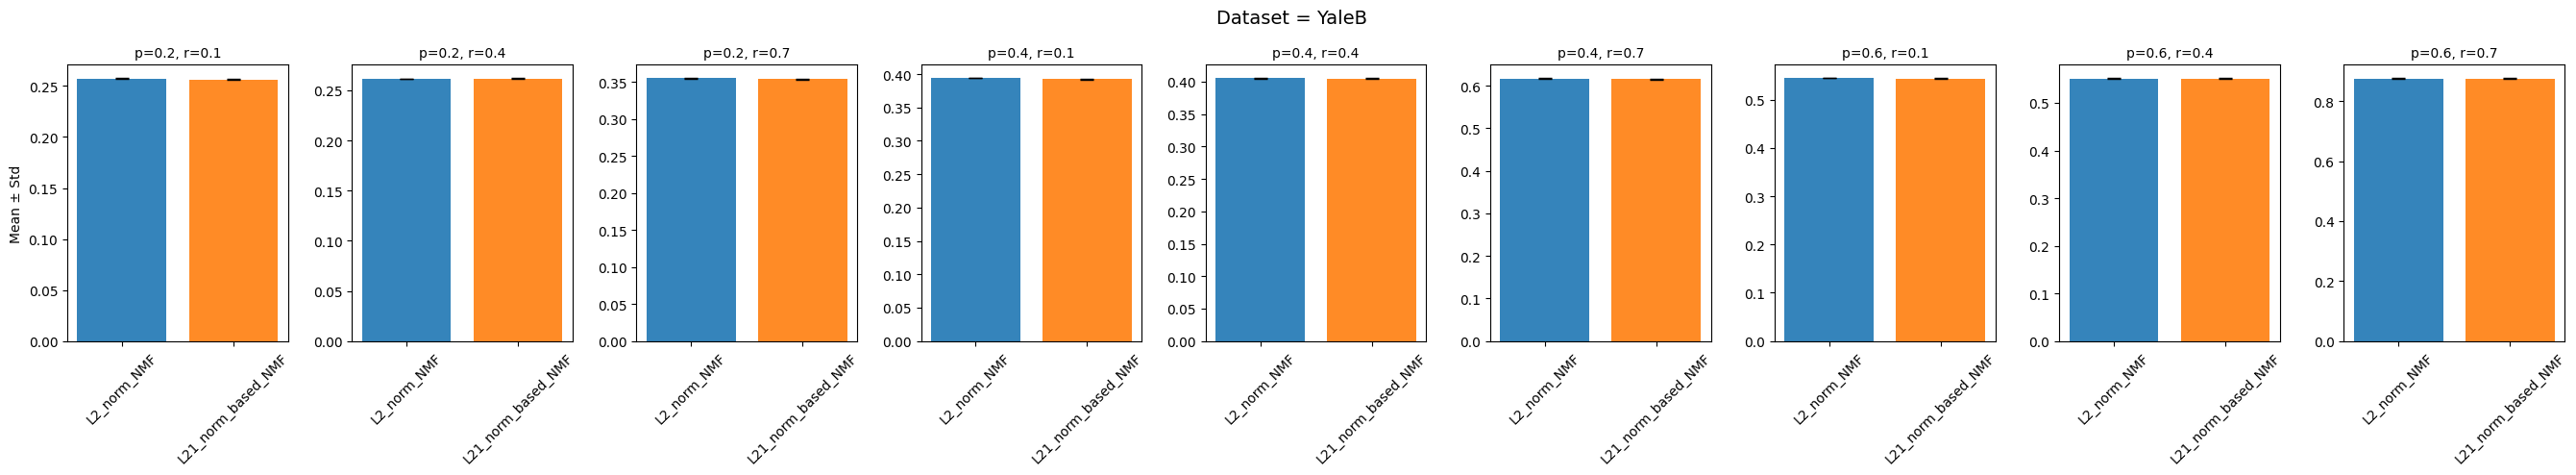

In [ ]:
plot_rre()

### 2.2 Evaluate Clustering Performance

1. Accuracy.
    
    $$ Acc(Y, Y_{pred}) = \frac{1}{n}\sum\limits_{i=1}^n 1\{Y_{pred}(i) == Y(i)\}$$
        
2. Normalized Mutual Information (NMI).

    $$ NMI(Y, Y_{pred}) = \frac{2 * I(Y, Y_{pred})}{H(Y) + H(Y_{pred})} $$
    
   where $ I(\cdot,\cdot) $ is mutual information and $ H(\cdot) $ is entropy.

In [ ]:
from collections import Counter
from sklearn.cluster import KMeans

def assign_cluster_label(X, Y):
    kmeans = KMeans(n_clusters=len(set(Y))).fit(X)
    Y_pred = np.zeros(Y.shape)
    for i in set(kmeans.labels_):
        ind = kmeans.labels_ == i
        Y_pred[ind] = Counter(Y[ind]).most_common(1)[0][0] # assign label.
    return Y_pred

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import normalized_mutual_info_score

# Save Acc and NMI records
try:
    acc_nmi_records
except NameError:
    acc_nmi_records = []
    

# Evaluate Acc and NMI

def calculate_acc_nmi(WH_records):

    datasets = ["ORL", "YaleB"]
    methods = ["L2_norm_NMF","L21_norm_based_NMF"] # 
    ps = [0.2,0.4,0.6]
    rs = [0.1,0.4,0.7]
    seed = range(5)

    acc_nmi_records = []

    for p, r, name, method in product(ps, rs, datasets, methods):
        acc_list = []
        nmi_list = []
        for t in seed:
            H = WH_records[name, method, p, r, t, "H"]
            Y_hat = WH_records[name, method, p, r, t, "Y_hat"]
        
            Y_pred = assign_cluster_label(H.T,Y_hat)
            acc = accuracy_score(Y_hat, Y_pred)
            acc_list.append(acc)
            nmi = normalized_mutual_info_score(Y_hat, Y_pred)
            nmi_list.append(nmi)
        
        acc_mean, acc_std = round(float(np.mean(acc_list)),8), round(float(np.std(acc_list)),8)
        nmi_mean, nmi_std = round(float(np.mean(nmi_list)),8), round(float(np.std(nmi_list)),8)
        
        logger.info(f'ACC score on ({name}) using ({method}) with p = {p}, r = {r}, mean = {acc_mean}, std = {acc_std}')
        logger.info(f'NMI score on ({name}) using ({method}) with p = {p}, r = {r}, mean = {nmi_mean}, std = {nmi_std}')

        acc_nmi_records.append({
        "dataset": name,
        "nmf_method": method,
        "p": float(p),
        "r": float(r),
        "acc_mean": acc_mean,
        "acc_std": acc_std,
        "nmi_mean": nmi_mean,
        "nmi_std": nmi_std
        })
        
    return acc_nmi_records

In [ ]:
# Summary for acc and NMI records
acc_nmi_records = calculate_acc_nmi(WH_records)
df_acc_nmi = pd.DataFrame(
    acc_nmi_records,
    columns=["dataset","nmf_method","p","r","acc_mean","acc_std","nmi_mean","nmi_std"]
).sort_values(["dataset","nmf_method","p","r"])

print(df_acc_nmi)
result_logger.info(f'\nResults for ACC and NMI')
result_logger.info(f'{df_acc_nmi}')

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# Summary for the combination of p and r (Acc / NMI)
datasets = df_acc_nmi["dataset"].unique()

for ds in datasets:
    df_ds = df_acc_nmi[df_acc_nmi["dataset"] == ds]
    prs = df_ds[["p","r"]].drop_duplicates().sort_values(["p","r"]).values

    # Accuracy Summary
    acc_records = []
    for ps, rs in prs:
        sub_l2 = df_ds[(df_ds["nmf_method"]=="L2_norm_NMF") &
                       (df_ds["p"]==ps) & (df_ds["r"]==rs)]
        sub_l21 = df_ds[(df_ds["nmf_method"]=="L21_norm_based_NMF") &
                        (df_ds["p"]==ps) & (df_ds["r"]==rs)]
        acc_records.append([
            f"p={ps}, r={rs}",
            "L2",
            float(sub_l2["acc_mean"].values[0]),
            float(sub_l2["acc_std"].values[0]),
            "L21",
            float(sub_l21["acc_mean"].values[0]),
            float(sub_l21["acc_std"].values[0]),
        ])
    acc_summary = pd.DataFrame(acc_records, columns=[
        "pr", "L2", "L2_mean", "L2_std",
        "L21", "L21_mean", "L21_std"
    ])
    print(f"\nDataset {ds} Accuracy Summary")
    print(acc_summary)
    result_logger.info(f"\nDataset {ds} ACC Summary")
    result_logger.info(f'{acc_summary}')
    
    # NMI Summary
    nmi_records = []
    for ps, rs in prs:
        sub_l2 = df_ds[(df_ds["nmf_method"]=="L2_norm_NMF") &
                       (df_ds["p"]==ps) & (df_ds["r"]==rs)]
        sub_l21 = df_ds[(df_ds["nmf_method"]=="L21_norm_based_NMF") &
                        (df_ds["p"]==ps) & (df_ds["r"]==rs)]
        nmi_records.append([
            f"p={ps}, r={rs}",
            "L2",
            float(sub_l2["nmi_mean"].values[0]),
            float(sub_l2["nmi_std"].values[0]),
            "L21",
            float(sub_l21["nmi_mean"].values[0]),
            float(sub_l21["nmi_std"].values[0]),
        ])
    nmi_summary = pd.DataFrame(nmi_records, columns=[
        "pr", "L2", "L2_mean", "L2_std",
        "L21", "L21_mean", "L21_std"
    ])
    print(f"\nDataset {ds} NMI Summary")
    print(nmi_summary)
    result_logger.info(f"\nDataset {ds} NMI Summary")
    result_logger.info(f'{nmi_summary}')


Dataset ORL Accuracy Summary
             pr  L2   L2_mean    L2_std  L21  L21_mean   L21_std
0  p=0.2, r=0.1  L2  0.189444  0.007115  L21  0.193333  0.008352
1  p=0.2, r=0.4  L2  0.180000  0.005386  L21  0.188333  0.010000
2  p=0.2, r=0.7  L2  0.185556  0.005666  L21  0.180000  0.003685
3  p=0.4, r=0.1  L2  0.185556  0.006894  L21  0.188333  0.007328
4  p=0.4, r=0.4  L2  0.183889  0.005092  L21  0.180556  0.007244
5  p=0.4, r=0.7  L2  0.175556  0.006667  L21  0.184444  0.010628
6  p=0.6, r=0.1  L2  0.187778  0.005443  L21  0.190556  0.003768
7  p=0.6, r=0.4  L2  0.182222  0.008535  L21  0.176667  0.008714
8  p=0.6, r=0.7  L2  0.179444  0.010334  L21  0.179444  0.007577

Dataset ORL NMI Summary
             pr  L2   L2_mean    L2_std  L21  L21_mean   L21_std
0  p=0.2, r=0.1  L2  0.368879  0.018274  L21  0.375511  0.014752
1  p=0.2, r=0.4  L2  0.361946  0.008574  L21  0.364057  0.014811
2  p=0.2, r=0.7  L2  0.369787  0.009144  L21  0.350706  0.012485
3  p=0.4, r=0.1  L2  0.358109  0.01

In [ ]:
# Table Visualization
metrics_2 = ["acc_mean","acc_std","nmi_mean","nmi_std"]
print('The value of columns is r while the value of index is p.')
for metric, name, method in product(metrics_2, datasets, methods):
    print('-')
    print(f'{metric} for dataset "{name}" using algorithm "{method}":')
    result_logger.info(f'{metric} for dataset "{name}" using algorithm "{method}":')
    sub = df_acc_nmi[(df_acc_nmi["dataset"] == name) & (df_acc_nmi["nmf_method"] == method)]
    table_visual(sub, metric)

The value of columns is r while the value of index is p.
-
acc_mean for dataset "ORL" using algorithm "L2_norm_NMF":
r         0.1       0.4       0.7
p                                
0.2  0.189444  0.180000  0.185556
0.4  0.185556  0.183889  0.175556
0.6  0.187778  0.182222  0.179444
-
acc_mean for dataset "ORL" using algorithm "L21_norm_based_NMF":
r         0.1       0.4       0.7
p                                
0.2  0.193333  0.188333  0.180000
0.4  0.188333  0.180556  0.184444
0.6  0.190556  0.176667  0.179444
-
acc_mean for dataset "YaleB" using algorithm "L2_norm_NMF":
r         0.1       0.4       0.7
p                                
0.2  0.082965  0.083149  0.082689
0.4  0.086556  0.084438  0.086280
0.6  0.087017  0.084254  0.081768
-
acc_mean for dataset "YaleB" using algorithm "L21_norm_based_NMF":
r         0.1       0.4       0.7
p                                
0.2  0.082965  0.084346  0.083978
0.4  0.083517  0.084070  0.081676
0.6  0.085727  0.083610  0.081123
-
acc

In [ ]:
# Compare algorithm in the same p,r,dataset with mean and std metrics.

def plot_acc_nmi():
    # Transfer dict into dataframe
    acc_nmi_s = ['ACC','NMI']
    ps = [0.2,0.4,0.6]
    rs = [0.1,0.4,0.7]

    
    new_records = []
    for _, row in df_acc_nmi.iterrows():
        for acc_nmi, mean_key, std_key in [
            ("ACC", "acc_mean", "acc_std"),
            ("NMI", "nmi_mean", "nmi_std")
        ]:
            new_records.append({
                "dataset": row["dataset"],
                "method": row["nmf_method"],
                "p": row["p"],
                "r": row["r"],
                "mean": row[mean_key],
                "std": row[std_key],
                "acc_nmi": acc_nmi
            })

    df = pd.DataFrame(new_records)

    colors = ["#1f77b4", "#ff7f0e"]

    # plot
    for dataset in datasets:
        for acc_nmi in acc_nmi_s:
            fig, axes = plt.subplots(
                nrows=1, ncols=len(ps)*len(rs),
                figsize=(3*len(ps)*len(rs), 5), 
                sharey=False
            )

            for k, (p, r) in enumerate(product(ps, rs)):
                ax = axes[k]
                sub = df[(df["dataset"] == dataset) &
                        (df["p"] == p) &
                        (df["r"] == r) &
                        (df["acc_nmi"] == acc_nmi)]

                x = range(len(methods))
                means = sub.set_index("method").loc[methods]["mean"]
                stds  = sub.set_index("method").loc[methods]["std"]

                for xi, (m, mean, std) in enumerate(zip(methods, means, stds)):
                    ax.bar(xi, mean, yerr=std, capsize=5, alpha=0.9,
                        color=colors[xi], label=m if k == 0 else "")
                ax.set_xticks(x)
                ax.set_xticklabels(methods, rotation=45)
                ax.set_title(f"p={p}, r={r}, metric={acc_nmi}", fontsize=10)
                if k == 0:
                    ax.set_ylabel("Mean ± Std")

            plt.suptitle(f"Dataset = {dataset}", fontsize=14)
            plt.tight_layout()
            plt.show()

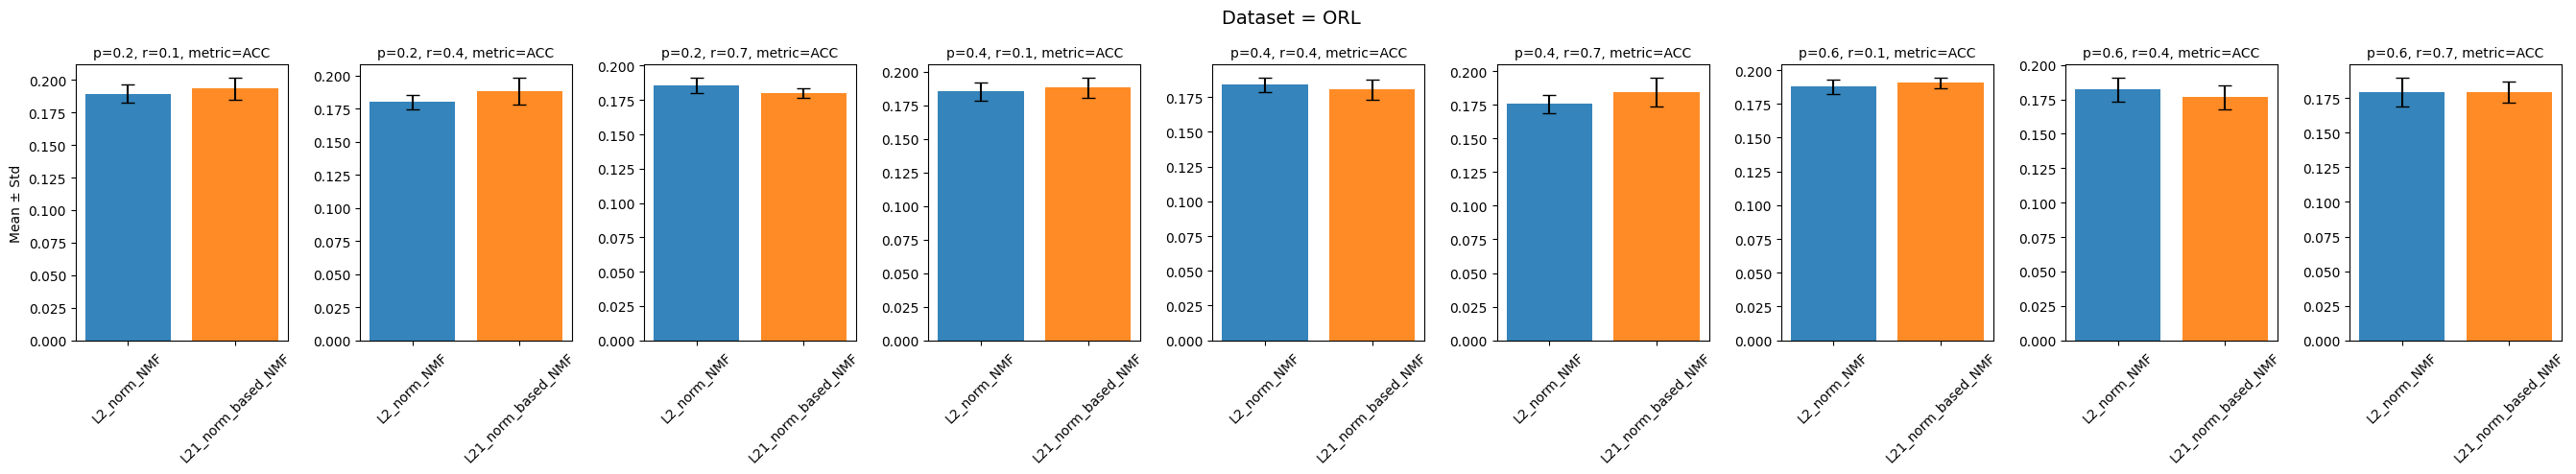

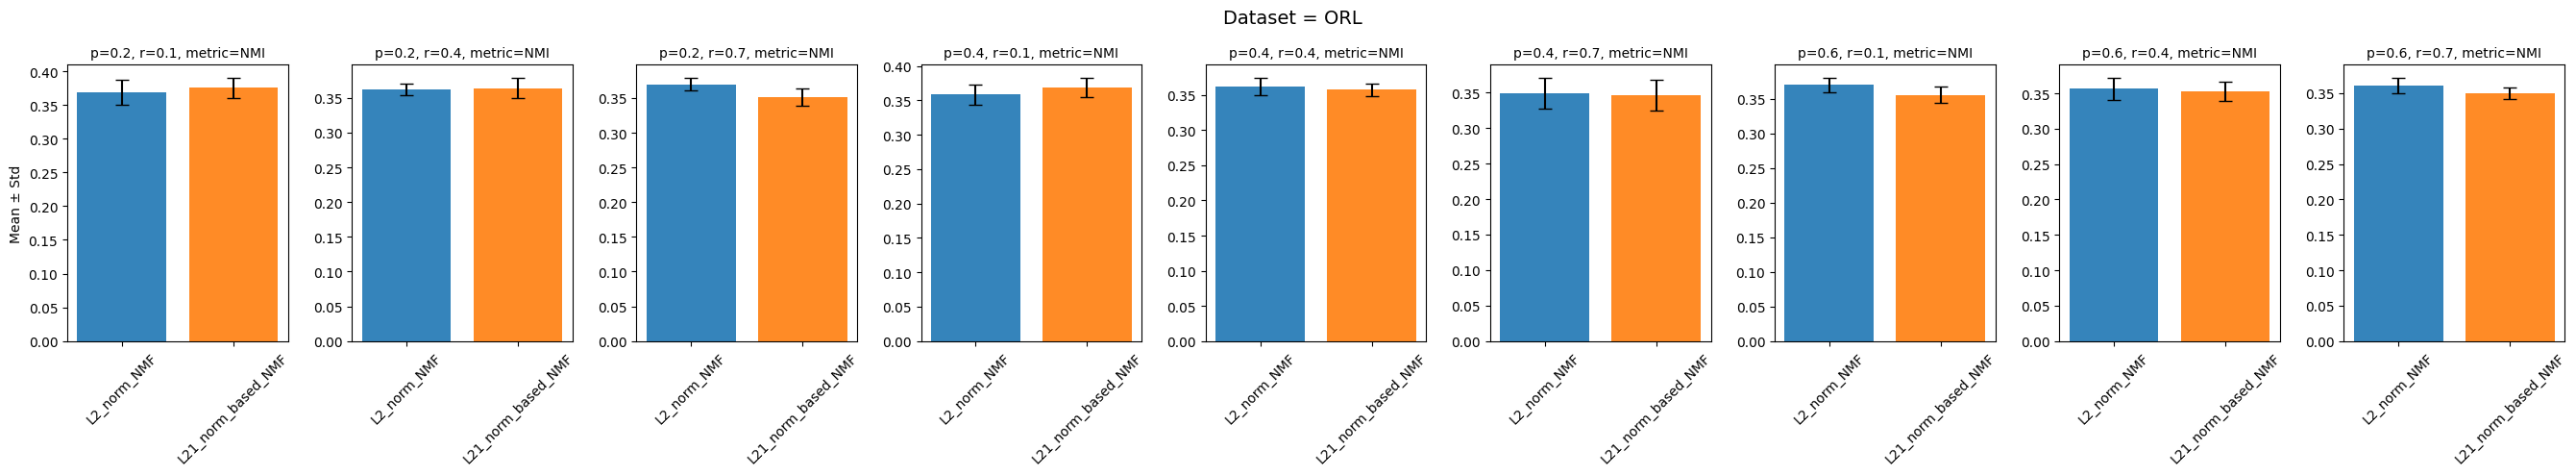

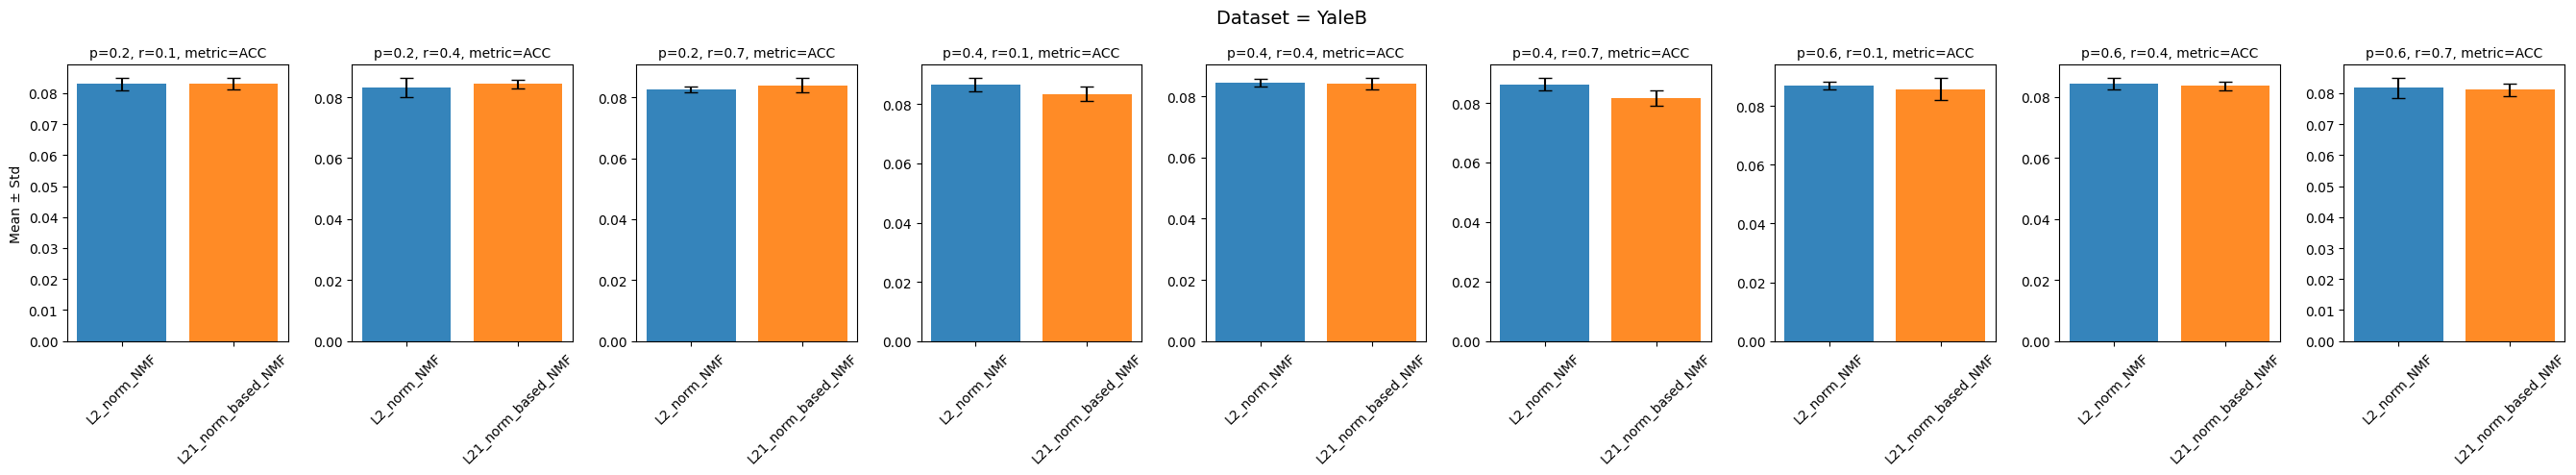

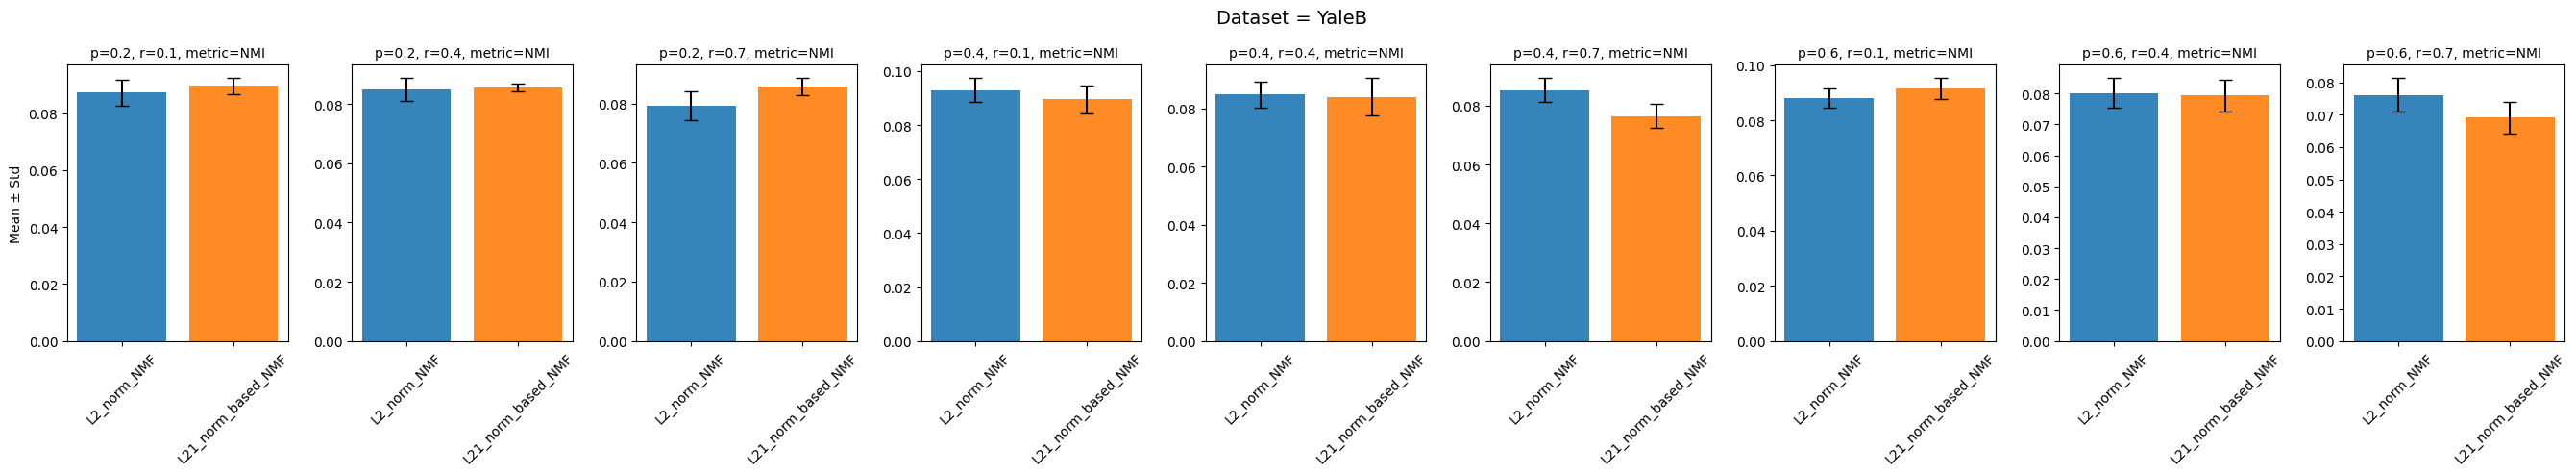

In [ ]:
plot_acc_nmi()